# Lane 3: Evaluator-Optimizer

Owner: Nina Zhao. Development notebook; finished cells are copied into `notebook.ipynb` section 3 at assembly. See `docs/` and `setup.md`.

In [1]:
import json
import re
import sys
import textwrap

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, "..")  # this notebook lives in dev/; make src/ importable

from src import llm, tools  # noqa: E402
from src.llm import chat, handoff  # noqa: E402

Generate an analysis, score it against explicit criteria, refine it from the feedback, at most two rounds.

**Contract:** `generate_analysis(symbol, context) -> str`; `evaluate(text, criteria) -> {"score": 1-10, "pass": bool, "feedback": list[str]}`, each feedback item naming the criterion it failed; `refine(text, feedback) -> str`; `evaluator_optimizer(generate, criteria, max_rounds=2) -> {"final": str, "history": [{"round", "score", "pass", "feedback"}]}`.
`generate` is a zero-argument callable so the agent can pass its own report writer.

### How the loop works

Two agents take turns. The **Writer** drafts an analysis. The **Critic** checks the draft against a numbered checklist and the data it was written from, one criterion at a time, and says which criteria failed and why. The Writer then revises the draft to fix exactly those points. The Critic grades the revision, and the loop stops when every criterion is met or after two revisions.

Design choices:

- **Criteria are checkable, not vague.** Each one names something the Critic can look for in the text and verify in the data ("states the profit margin percent"), not a judgment like "is insightful".
- **The criteria carry the reference data.** `make_criteria` appends the data the analysis was written from, so the Critic checks that a figure is *correct*, not only that one is present. Lane 4 builds its criteria the same way.
- **The score is computed, not guessed.** The Critic marks each criterion met or not met, and the score is the share met, scaled to 10. In team testing, a model asked for a 1-to-10 score directly gave the same text scores about two points apart; a per-criterion yes or no is more stable, and the feedback names exactly what to fix.
- **The loop keeps the best draft, and always ends with its grade.** A revision can score lower than the draft it revised, so `final` is the best-scoring draft (the latest one on a tie), and `history[-1]` is always the grade of `final`. `history[0]` records what the first draft got wrong. The agent in Lane 4 reads both.
- **The loop is bounded**: at most two revisions (five LLM calls in the worst case), so it always terminates.

### Reference data and criteria

In [2]:
# The data one analysis is written from: the six-month price summary, the fundamentals, and the
# recent headlines, all from the committed cache, as one JSON string. The Writer reads it and the
# Critic checks every figure against it.
def build_context(symbol):
    prices = tools.get_prices(symbol)
    fundamentals = tools.get_fundamentals(symbol)
    view = {
        # The 127 daily closes are dropped; the summary figures are what an analysis quotes.
        "prices_6mo": {k: v for k, v in prices.items() if k not in ("dates", "close")},
        # Two decimals: Yahoo's P/E arrives as 38.591274, which nobody quotes.
        "fundamentals": {k: round(v, 2) if isinstance(v, float) else v for k, v in fundamentals.items()},
        "headlines": [article["title"] for article in tools.get_news(symbol)],
    }
    return json.dumps(view, indent=1)


# The Critic's checklist for this lane's demonstration. Every criterion can be checked in the text
# and verified against the reference data. Lane 4 passes its own list in the same numbered format.
CRITERIA = """\
1. States the share price change over the six months as a percent, and the last closing price.
2. States total revenue with its unit, and the revenue growth percent.
3. States the profit margin percent.
4. States the trailing or forward P/E ratio and says in one phrase what it suggests about valuation.
5. Refers to at least one specific headline from the reference data.
6. Names at least two distinct risks, each supported by a figure or a headline in the reference data.
7. Every figure in the text matches the reference data (rounding and unit changes such as 4905.54 billion as 4.91 trillion are fine), and the text states no fact or comparison the data does not contain.
8. Makes no recommendation to buy, sell, or hold (saying that no recommendation is made is fine).
9. Is written in plain words for a reader: no data field names such as revenue_b or change_pct.
"""


# The checklist plus the data the text was written from, so the Critic can check that a figure is
# correct, not only that one is present.
def make_criteria(context, criteria=CRITERIA):
    return f"{criteria}\nReference data:\n{context}"

### Writer: the first draft

`generate_analysis` is a deliberately plain prompt: it does not show the Writer the checklist. A first draft written this way usually misses a few criteria, which gives the Critic something real to catch and the loop something to improve. Inside the agent (Lane 4), the Writer's own report function takes this place.

In [3]:
WRITER = """\
You are the Writer on an investment research team. Write a short research analysis of the stock
below, using only the data given. Do not recommend buying, selling, or holding.
"""


# One plain chat() call. Exists so the loop can be demonstrated without Lane 2.
def generate_analysis(symbol, context):
    return chat(WRITER, f"Stock: {symbol}\n\nData:\n{context}", max_tokens=1500, agent="Writer")

### Critic: grading against the criteria

The Critic replies in JSON with one verdict per criterion. The code then checks the reply before trusting it: it must contain a verdict for every numbered criterion, each with a true or false `met`. A reply that fails the check, or a call that fails (for example a reply cut off at the token limit, which happened about once in 100 calls in team testing), is retried once. The score, pass flag, and feedback list are computed from the verdicts in code, so the result always has all three keys.

In [4]:
CRITIC = """\
You are the Critic on an investment research team. Judge the text against each numbered criterion
separately, using the reference data to check every figure. A criterion is met only if the text
clearly satisfies it.
Reply with JSON only, in exactly this shape:
{"criteria": [{"number": 1, "reason": "<one sentence>", "met": true}, ...]}
Include every criterion, in order. Write the reason first, then set "met" (true or false) to agree
with it. For a criterion that is not met, the reason says what is missing or wrong, specifically
enough for a writer to fix it.
"""


# How many numbered criteria the checklist has (the lines before the reference data that start "N.").
def count_criteria(criteria):
    checklist = criteria.split("Reference data:")[0]
    return len(re.findall(r"^\s*\d+\.", checklist, flags=re.MULTILINE))


# The Critic's verdicts, checked: one per criterion, each with a number and a true/false "met".
# Raises ValueError on a reply that does not have that shape.
def parse_verdicts(reply, expected):
    verdicts = reply.get("criteria")
    if not isinstance(verdicts, list) or len(verdicts) != expected:
        raise ValueError(f"expected {expected} verdicts, got {verdicts!r:.200}")
    checked = []
    for verdict in verdicts:
        met = verdict.get("met") if isinstance(verdict, dict) else None
        if isinstance(met, str) and met.lower() in ("true", "false"):
            met = met.lower() == "true"  # a model occasionally writes "true" as a string
        if not isinstance(met, bool) or "number" not in verdict:
            raise ValueError(f"malformed verdict: {verdict!r:.200}")
        checked.append({"number": verdict["number"], "met": met, "reason": str(verdict.get("reason", ""))})
    return checked


# One Critic call (retried once on a bad reply) -> {"score", "pass", "feedback", "checks"}. The score
# is the share of criteria met, out of 10; feedback lists only the failed criteria, each named.
def evaluate(text, criteria):
    expected = count_criteria(criteria)
    user = f"CRITERIA:\n{criteria}\n\nTEXT TO JUDGE:\n{text}"
    for attempt in (1, 2):
        try:
            reply = chat(CRITIC, user, json_mode=True, max_tokens=1500, agent="Critic")
            checks = parse_verdicts(reply, expected)
            break
        except ValueError as error:  # truncated, not JSON, or the wrong shape
            if attempt == 2:
                raise
            print(f"Critic reply rejected ({error}); asking again.")
    failed = [f"Criterion {c['number']}: {c['reason']}" for c in checks if not c["met"]]
    met = len(checks) - len(failed)
    return {"score": round(10 * met / len(checks)), "pass": not failed, "feedback": failed, "checks": checks}

### Writer: revising from the feedback

`refine` gives the Writer the Critic's feedback and the draft, and asks it to fix those points and change nothing else. The loop also passes the criteria and reference data, so a figure the Writer adds comes from the data rather than from memory. `reference` is optional, so `refine(text, feedback)` still matches the contract.

In [5]:
REVISER = """\
You are the Writer on an investment research team, revising your analysis after the Critic's
review. Fix every point in the feedback, and take any figure you add or correct from the reference
data only. Keep everything the feedback does not mention as it is. Reply with the revised analysis
only, with no commentary on what changed.
"""


# feedback is the list from evaluate(); reference is the criteria and data, when the caller has them.
def refine(text, feedback, reference=""):
    notes = "\n".join(f"- {item}" for item in feedback)
    data = f"\n\nCRITERIA AND REFERENCE DATA:\n{reference}" if reference else ""
    user = f"FEEDBACK:\n{notes}\n\nANALYSIS TO REVISE:\n{text}{data}"
    return chat(REVISER, user, max_tokens=1500, agent="Writer")

### The loop

In [6]:
# generate() -> evaluate -> refine -> evaluate, stopping on a pass or after max_rounds revisions.
# Returns the best-scoring draft as "final"; history[-1] is always the grade of "final", and
# history[0] records what the first draft got wrong. "drafts" keeps every version, in order.
def evaluator_optimizer(generate, criteria, max_rounds=2):
    text = generate()
    drafts = [text]
    handoff("Writer", "Critic", f"first draft, {len(text.split())} words")
    check = evaluate(text, criteria)
    history = [{"round": 0, **check}]
    for round_number in range(1, max_rounds + 1):
        if check["pass"]:
            break
        handoff("Critic", "Writer", f"score {check['score']}/10, {len(check['feedback'])} criteria to fix")
        text = refine(text, check["feedback"], reference=criteria)
        drafts.append(text)
        handoff("Writer", "Critic", f"revision {round_number}, {len(text.split())} words")
        check = evaluate(text, criteria)
        history.append({"round": round_number, **check})
    # Keep the best-scoring draft (the latest on a tie): a revision can score lower than the draft it
    # revised. When the best is not the last, its grade is repeated at the end, marked "kept", so
    # history[-1] is always the grade of "final". No extra LLM call is made.
    best = max(range(len(history)), key=lambda i: (history[i]["score"], i))
    if best != len(history) - 1:
        history.append({**history[best], "kept": True})
        handoff("Critic", "Writer", f"keeping round {best} ({history[best]['score']}/10); later revisions scored lower")
    return {"final": drafts[best], "history": history, "drafts": drafts}

## Demonstration

Run the function on cached data and produce the table and figure described above. Keep printed output narrow enough for a PDF page.

Put demo code inside the `if __name__ == "__main__":` block below. It runs normally in this notebook, but not when another lane imports this notebook's `.py` export, so importing your functions never re-runs your LLM calls and plots.

Three drafts go through the loop. The first is a full analysis of AAPL from the plain Writer prompt: when it meets every criterion, the loop stops after one grading, and when it does not, it shows how far two revisions take a draft that is already close. The other two are deliberately thin two-sentence drafts of NVDA and AAPL, which miss most of the checklist and show the loop finding the gaps and the Writer filling them. Each line below is one handoff between the Writer and the Critic.

In [7]:
if __name__ == "__main__":
    from IPython.display import display

    # A thin first draft: two sentences, so it misses most criteria on purpose.
    def thin_draft(symbol, context):
        prompt = f"In two sentences, describe {symbol} using this data:\n{context}"
        return chat(WRITER, prompt, max_tokens=300, agent="Writer")

    cases = [
        ("AAPL, full draft", "AAPL", generate_analysis),
        ("NVDA, thin draft", "NVDA", thin_draft),
        ("AAPL, thin draft", "AAPL", thin_draft),
    ]
    demo_start = len(llm.CALL_LOG)  # count only this demonstration's calls, even after a re-run
    runs = {}
    for label, symbol, writer in cases:
        print(f"\n=== {label} ===")
        context = build_context(symbol)
        runs[label] = evaluator_optimizer(
            lambda s=symbol, c=context, w=writer: w(s, c), make_criteria(context)
        )
        final = runs[label]["history"][-1]
        handoff("Critic", "Coordinator", f"final score {final['score']}/10, pass={final['pass']}")


=== AAPL, full draft ===
Writer → Critic: first draft, 417 words
Critic → Writer: score 8/10, 2 criteria to fix
Writer → Critic: revision 1, 375 words
Critic → Writer: score 9/10, 1 criteria to fix
Writer → Critic: revision 2, 375 words
Critic → Coordinator: final score 10/10, pass=True

=== NVDA, thin draft ===
Writer → Critic: first draft, 70 words
Critic → Writer: score 6/10, 4 criteria to fix
Writer → Critic: revision 1, 145 words
Critic → Coordinator: final score 10/10, pass=True

=== AAPL, thin draft ===
Writer → Critic: first draft, 65 words
Critic → Writer: score 6/10, 4 criteria to fix
Writer → Critic: revision 1, 148 words
Critic → Coordinator: final score 10/10, pass=True


### Score per round

One row per Critic grading. `failed` lists the numbers of the criteria the draft did not meet. When a revision scored lower than an earlier draft, a last row marks the earlier draft kept as final.

,draft,round,score,pass,failed,note
0,"AAPL, full draft",0,8,False,"4, 7",
1,"AAPL, full draft",1,9,False,7,
2,"AAPL, full draft",2,10,True,none,
3,"NVDA, thin draft",0,6,False,"2, 4, 5, 6",
4,"NVDA, thin draft",1,10,True,none,
5,"AAPL, thin draft",0,6,False,"2, 4, 5, 6",
6,"AAPL, thin draft",1,10,True,none,


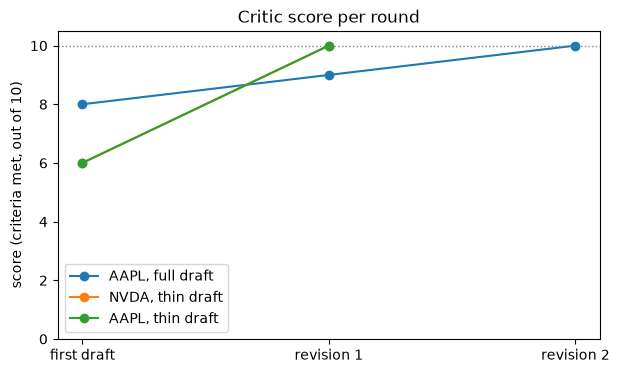

In [8]:
if __name__ == "__main__":
    rows = []
    for label, run in runs.items():
        for h in run["history"]:
            failed = [c["number"] for c in h["checks"] if not c["met"]]
            rows.append({"draft": label, "round": h["round"], "score": h["score"], "pass": h["pass"],
                         "failed": ", ".join(str(n) for n in failed) or "none",
                         "note": "best draft, kept as final" if h.get("kept") else ""})
    display(pd.DataFrame(rows))

    fig, ax = plt.subplots(figsize=(7, 4))
    for label, run in runs.items():
        graded = [h for h in run["history"] if not h.get("kept")]  # one point per grading
        ax.plot([h["round"] for h in graded], [h["score"] for h in graded], marker="o", label=label)
    ax.axhline(10, color="gray", linestyle=":", linewidth=1)
    ax.set_xticks([0, 1, 2], ["first draft", "revision 1", "revision 2"])
    ax.set(title="Critic score per round", ylabel="score (criteria met, out of 10)", ylim=(0, 10.5))
    ax.legend()
    plt.show()

### Before and after

The draft whose score rose the most. First, each criterion's verdict on the first draft and on the final text; then the Critic's feedback on the first draft; then the two texts, so the gap the feedback named can be seen filled in the revision.

In [9]:
if __name__ == "__main__":
    def gain(label):
        history = runs[label]["history"]
        return history[-1]["score"] - history[0]["score"]

    best = max(runs, key=gain)
    run = runs[best]
    first, last = run["history"][0], run["history"][-1]
    criteria_lines = [line for line in CRITERIA.splitlines() if re.match(r"\s*\d+\.", line)]
    mark = {True: "met", False: "NOT met"}
    display(pd.DataFrame({
        "criterion": [textwrap.shorten(line, 70) for line in criteria_lines],
        "first draft": [mark[c["met"]] for c in first["checks"]],
        "final": [mark[c["met"]] for c in last["checks"]],
    }))

    def show(title, text):
        print(f"\n{title}\n" + "-" * len(title))
        for paragraph in text.split("\n"):
            print(textwrap.fill(paragraph, 100) if paragraph.strip() else "")

    print(f"Draft: {best}. Score {first['score']}/10 -> {last['score']}/10 "
          f"after {len(run['drafts']) - 1} revision(s).")
    show("What the Critic said about the first draft", "\n".join(first["feedback"]) or "no failed criteria")
    show("First draft", run["drafts"][0])
    show("Final text", run["final"])

,criterion,first draft,final
0,1. States the share price change over the six ...,met,met
1,"2. States total revenue with its unit, and the...",NOT met,met
2,3. States the profit margin percent.,met,met
3,4. States the trailing or forward P/E ratio an...,NOT met,met
4,5. Refers to at least one specific headline fr...,NOT met,met
5,"6. Names at least two distinct risks, each sup...",NOT met,met
6,7. Every figure in the text matches the refere...,met,met
7,"8. Makes no recommendation to buy, sell, or ho...",met,met
8,9. Is written in plain words for a reader: no ...,met,met


Draft: NVDA, thin draft. Score 6/10 -> 10/10 after 1 revision(s).

What the Critic said about the first draft
------------------------------------------
Criterion 2: The text gives revenue growth of 105.9% but never states total revenue (302.97 billion)
or its unit.
Criterion 4: The text cites 28.1x trailing and 14.17x forward earnings but does not say what either
ratio suggests about valuation.
Criterion 5: The text contains no reference to any of the listed headlines.
Criterion 6: The text lists no risks at all, so no two risks supported by data or headlines are
named.

First draft
-----------
NVIDIA Corporation (NVDA) is a Technology sector semiconductor company with a $5.37 trillion market
cap, trading at 28.1x trailing and 14.17x forward earnings, with revenue growth of 105.9%, earnings
growth of 127.8%, and a 63.7% profit margin. Over the past six months, NVDA gained 24.77% to close
at 222.27, within a range of 164.79 to 235.2 and near its 52-week high of 236.54, on average volum

### LLM calls by agent

Every call goes through `chat()`, which records the agent that made it. One loop costs at most five calls: one first draft, and up to two revisions with a grading after each draft.

In [10]:
if __name__ == "__main__":
    calls = pd.DataFrame(llm.CALL_LOG[demo_start:])
    calls["tokens"] = calls["prompt_tokens"].fillna(0) + calls["completion_tokens"].fillna(0)
    display(calls.groupby("agent").agg(calls=("agent", "size"), tokens=("tokens", "sum"),
                                       seconds=("seconds", "sum")).astype(int))

,calls,tokens,seconds
agent,,,
Critic,7,11155,20
Writer,7,9080,34
